## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Reproducibility: neural nets are randomly initialized and DataLoader shuffles randomly.
# Without seeding, you'll get a different R^2 every single run
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 2. Load and explore the data

In [5]:
df = pd.read_excel('Concrete_Data.xls')
print(df.shape)
df.head()

(1030, 9)


,Cement,BFS,FlyAsh,Water,Superplasticizer,CoarseAggreagate,FineAggregate,Age,ConcreteStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [6]:
df.describe().T  

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
BFS,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
FlyAsh,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
Water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
Superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
CoarseAggreagate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
FineAggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
Age,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
ConcreteStrength,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


In [7]:
df.isnull().sum()

Cement              0
BFS                 0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAggreagate    0
FineAggregate       0
Age                 0
ConcreteStrength    0
dtype: int64

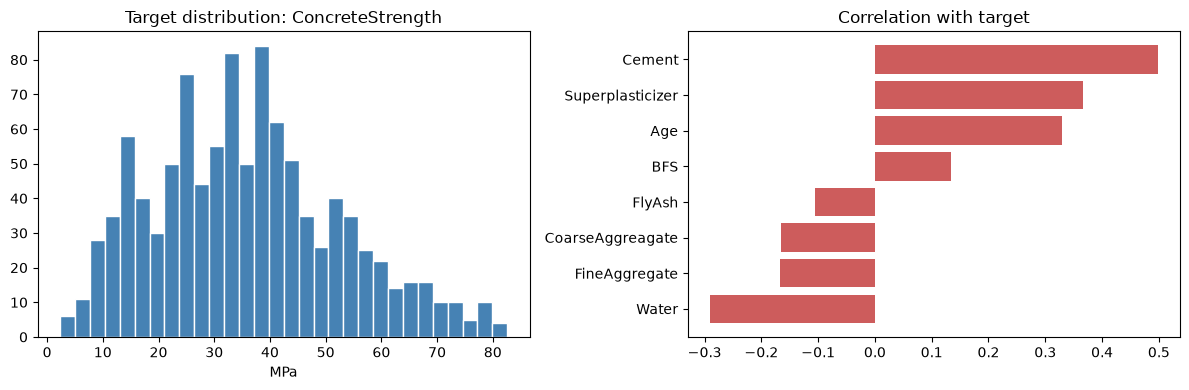

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(df['ConcreteStrength'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Target distribution: ConcreteStrength')
axes[0].set_xlabel('MPa')

corr = df.corr(numeric_only=True)['ConcreteStrength'].drop('ConcreteStrength').sort_values()
axes[1].barh(corr.index, corr.values, color='indianred')
axes[1].set_title('Correlation with target')
plt.tight_layout()
plt.show()

## 3. Train/test split — **before** scaling

In [9]:
X = df.drop("ConcreteStrength" , axis=1)        # axis = 1 means we are dropping a column, not a row
y = df["ConcreteStrength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
print(X_train.shape, X_test.shape)

(824, 8) (206, 8)


## 4. Feature scaling

In [10]:
scaler = StandardScaler()       # transforms each feature to mean 0, std 1
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train mean (should be ~0):", X_train_scaled.mean(axis=0).round(2))       # It should be ~0 because we subtracted the mean from each feature
print("Train std  (should be ~1):", X_train_scaled.std(axis=0).round(2))        # It should be ~1 because we divided by the std of each feature

Train mean (should be ~0): [-0.  0.  0.  0. -0.  0.  0. -0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Converting to PyTorch tensors

In [11]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)  # its float64 because pandas/NumPy default is float64, but PyTorch's default parameter dtype is float32. If your input tensor is float64 and your weights are float32, matrix multiplication will throw a dtype mismatch error.
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([824, 8]) torch.Size([824, 1])
torch.Size([206, 8]) torch.Size([206, 1])


## 6. Dataset & DataLoader

In [12]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

## 7. Building the ANN

In [30]:
class ANN(nn.Module):
    def __init__(self, input_dim):      # input__dim is a hyperparameter: the number of features in the input data
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),   # no activation: regression needs unrestricted real-valued output
        )

    def forward(self, x):
        return self.model(x)

model = ANN(X_train.shape[1])
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params}")


ANN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total trainable parameters: 3201


## 8. Loss function and optimizer

In [32]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

## 9. Training loop — with early stopping

In [33]:
EPOCHS = 300
PATIENCE = 20  # stop if val loss doesn't improve for this many consecutive epochs

train_losses, val_losses = [], []
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(EPOCHS):
    # ---- training ----
    model.train()                 # enables dropout/batchnorm training behavior (no-op here, but good habit)
    running_loss = 0.0
    for xb, yb in train_loader:   # xb and yb are mini-batches of data from the DataLoader that are automatically shuffled and batched for us
        optimizer.zero_grad()     # PyTorch accumulates gradients by default; must clear each step
        outputs = model(xb)       # forward pass
        loss = criterion(outputs, yb)
        loss.backward()           # backward pass: computes dL/dweight for every parameter
        optimizer.step()          # apply the gradient update
        running_loss += loss.item() * xb.size(0)
    epoch_train_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # ---- validation ----
    model.eval()                  # disables dropout/batchnorm training behavior
    running_val_loss = 0.0
    with torch.no_grad():         # don't build a computation graph -- saves memory & time, no backward needed
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item() * xb.size(0)
    epoch_val_loss = running_val_loss / len(test_dataset)
    val_losses.append(epoch_val_loss)

    # ---- early stopping check ----
    if epoch_val_loss < best_val_loss - 1e-4:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"epoch {epoch+1}/{EPOCHS} | train MSE={epoch_train_loss:.3f} | val MSE={epoch_val_loss:.3f}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1} "
              f"(no improvement for {PATIENCE} epochs). Best val MSE={best_val_loss:.3f}")
        break

epoch 1/300 | train MSE=1547.541 | val MSE=1488.703
epoch 20/300 | train MSE=131.021 | val MSE=119.220
epoch 40/300 | train MSE=57.555 | val MSE=57.065
epoch 60/300 | train MSE=36.516 | val MSE=42.723
epoch 80/300 | train MSE=30.536 | val MSE=38.893
epoch 100/300 | train MSE=27.490 | val MSE=38.947
epoch 120/300 | train MSE=23.299 | val MSE=36.670
epoch 140/300 | train MSE=20.724 | val MSE=37.400

Early stopping triggered at epoch 153 (no improvement for 20 epochs). Best val MSE=36.242


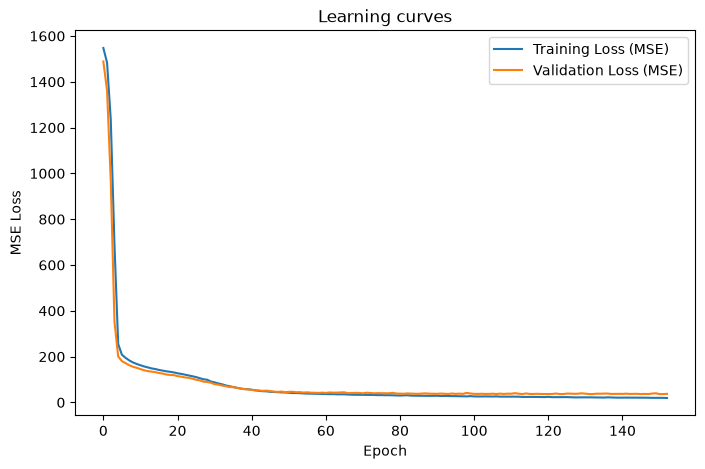

In [34]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(train_losses, label="Training Loss (MSE)")
ax.plot(val_losses, label="Validation Loss (MSE)")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Learning curves")
ax.legend()
plt.show()

## 10. Loading the best checkpoint and evaluating

In [35]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

train_mse = mean_squared_error(y_train_tensor.numpy(), train_preds.numpy())
test_mse = mean_squared_error(y_test_tensor.numpy(), test_preds.numpy())
test_mae = mean_absolute_error(y_test_tensor.numpy(), test_preds.numpy())
test_r2 = r2_score(y_test_tensor.numpy(), test_preds.numpy())

print(f"Train MSE : {train_mse:.3f}")
print(f"Test  MSE : {test_mse:.3f}")
print(f"Test  MAE : {test_mae:.3f} MPa")
print(f"Test  R^2 : {test_r2:.4f}")


Train MSE : 20.799
Test  MSE : 36.242
Test  MAE : 4.563 MPa
Test  R^2 : 0.8594
